In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Path to dataset files: /kaggle/input/waste-classification-data


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define your train and test directories based on the kagglehub path
# This dataset specifically puts images inside a 'DATASET' folder
train_dir = os.path.join(path, 'dataset', 'DATASET', 'TRAIN')
test_dir = os.path.join(path, 'dataset', 'DATASET', 'TEST')

# Sometimes the extraction skips the lowercase 'dataset' folder depending on the environment.
# If the above fails, uncomment and try these instead:
# train_dir = os.path.join(path, 'DATASET', 'TRAIN')
# test_dir = os.path.join(path, 'DATASET', 'TEST')

# 2. Set up parameters
batch_size = 32
img_height = 128
img_width = 128

# 3. Load the Training and Testing datasets
print("Loading Training Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

print("Loading Testing Data...")
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Classes found: {class_names}") # Should output ['O', 'R']

# Optimize data loading for faster training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 4. Build the CNN Model
num_classes = len(class_names)

model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Normalize pixels
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.5), # Helps prevent overfitting since this is a larger dataset
  layers.Dense(num_classes)
])

# 5. Compile the Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 6. Train the Model
epochs = 10
print("\nStarting Training...")
history = model.fit(
  train_ds,
  validation_data=test_ds,
  epochs=epochs
)

# 7. Find Final Accuracy
print("\nEvaluating final accuracy on the test set...")
loss, accuracy = model.evaluate(test_ds)
print(f"\nBefore tuning Test Accuracy: {accuracy * 100:.2f}%")

Loading Training Data...
Found 22564 files belonging to 2 classes.
Loading Testing Data...
Found 2513 files belonging to 2 classes.
Classes found: ['O', 'R']

Starting Training...
Epoch 1/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7819 - loss: 0.4841 - val_accuracy: 0.8878 - val_loss: 0.3463
Epoch 2/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8399 - loss: 0.3842 - val_accuracy: 0.8770 - val_loss: 0.3131
Epoch 3/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8546 - loss: 0.3467 - val_accuracy: 0.8953 - val_loss: 0.2694
Epoch 4/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8722 - loss: 0.3118 - val_accuracy: 0.8934 - val_loss: 0.2822
Epoch 5/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8880 - loss: 0.2829 - val_accuracy: 0.9045 - val_loss: 0.2775
Epoch 6/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8963 - loss: 0.2585 - val_accuracy: 0.8866 - val_loss: 0.3453
Epoch 7/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
print("\n--- Upgrading to a Fine-Tuned Pre-trained Model ---")

# 1. Load the pre-trained MobileNetV2 model (excluding its final classification layer)
# We use weights pre-trained on millions of images ('imagenet')
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model so we don't destroy its pre-trained knowledge
base_model.trainable = False

# 3. Build our new, smarter model on top of it
inputs = tf.keras.Input(shape=(img_height, img_width, 3))

# Data Augmentation (Random flips and rotations)
x = layers.RandomFlip('horizontal')(inputs)
x = layers.RandomRotation(0.2)(x)

# MobileNetV2 specifically expects pixel values between -1 and 1
x = layers.Rescaling(1./127.5, offset=-1)(x)

# Pass augmented images through the pre-trained base model
x = base_model(x, training=False)

# Convert features into a single vector
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Prevent overfitting

# Final classification layer (Predicts 'O' or 'R')
outputs = layers.Dense(num_classes)(x)
tuned_model = tf.keras.Model(inputs, outputs)

# 4. Compile the model
tuned_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 5. Phase 1: Train just the new top layers for a few epochs
print("\nPhase 1: Training the new classification head...")
history_head = tuned_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)



# Recompile with a MUCH lower learning rate so we don't wreck the pre-trained weights
tuned_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Continue training from where we left off
history_fine_tune = tuned_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10, # Total epochs: 5 from Phase 1 + 5 more for Phase 2
    initial_epoch=history_head.epoch[-1]
)

# 7. Find Final Accuracy
print("\nEvaluating fine-tuned accuracy on the test set...")
loss, accuracy = tuned_model.evaluate(test_ds)
print(f"\n✅ Final Fine-Tuned Accuracy: {accuracy * 100:.2f}%")


--- Upgrading to a Fine-Tuned Pre-trained Model ---

Phase 1: Training the new classification head...
Epoch 1/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8448 - loss: 0.3700 - val_accuracy: 0.8930 - val_loss: 0.2563
Epoch 2/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9144 - loss: 0.2252 - val_accuracy: 0.9053 - val_loss: 0.2322
Epoch 3/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9128 - loss: 0.2312 - val_accuracy: 0.9216 - val_loss: 0.1970
Epoch 4/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9133 - loss: 0.2281 - val_accuracy: 0.9053 - val_loss: 0.2218
Epoch 5/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9172 - loss: 0.2254 - val_accuracy: 0.9292 - val_loss: 0.1774
Epoch 6/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9096 - loss: 0.2296 - val_accuracy: 0.9367 - val_loss: 0.1666
Epoch 7/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9101 - loss: 0.2282 - val_accuracy: 0.9125 - val_

Gathering predictions. This might take a minute...

Classification Report
              precision    recall  f1-score   support

           O       0.88      0.97      0.92      1401
           R       0.96      0.83      0.89      1112

    accuracy                           0.91      2513
   macro avg       0.92      0.90      0.91      2513
weighted avg       0.91      0.91      0.91      2513



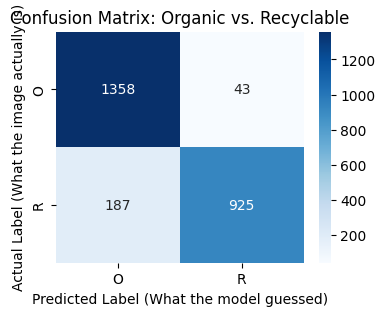

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Gathering predictions. This might take a minute...")

# 1. Extract the true labels and the model's predictions from the test set
y_true = []
y_pred = []

# Iterate through the test dataset batch by batch to ensure the order matches exactly
for images, labels in test_ds:
    y_true.extend(labels.numpy())

    # The model outputs "logits" (raw mathematical scores for each class)
    # We use np.argmax to find which class got the highest score
    batch_predictions = tuned_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(batch_predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Print the Classification Report
print("\n" + "="*50)
print("Classification Report")
print("="*50)
# Use the class names we extracted earlier ('O' and 'R')
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot the Confusion Matrix visually
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Organic vs. Recyclable')
plt.ylabel('Actual Label (What the image actually is)')
plt.xlabel('Predicted Label (What the model guessed)')
plt.show()